# Classification Problem

In [2]:
import pandas as pd
irisData=pd.read_csv("/datasets/Iris (1).csv")

In [3]:
irisData.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
!pip install ydata-profiling

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 392.1/392.1 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 97.3 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=712006fb58fa783e4bef5b4a3e4bc66b0f20d34b85b9b76b7a922f33e2fcaed2
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin


In [5]:
from ydata_profiling import ProfileReport
ProfileReport(irisData)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
x=irisData.iloc[:,1:-1]
y=irisData.Species

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0)

In [9]:
x_train.shape

(112, 4)

In [10]:
x_test.shape

(38, 4)

In [11]:
from sklearn.preprocessing import LabelEncoder
# from tensorflow.keras.utils import to_categorical

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Fit the encoder to your training data and transform both training and testing data
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# y_train_encoded=to_categorical(y_train_encoded)
# y_test_encoded=to_categorical(y_test_encoded)

In [12]:
y_train_encoded

array([1, 1, 2, 0, 2, 0, 0, 1, 2, 2, 2, 2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2,
       1, 0, 2, 1, 1, 1, 1, 2, 0, 0, 2, 1, 0, 0, 1, 0, 2, 1, 0, 1, 2, 1,
       0, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 1, 2,
       2, 0, 0, 0, 1, 1, 0, 0, 1, 0, 2, 1, 2, 1, 0, 2, 0, 2, 0, 0, 2, 0,
       2, 1, 1, 1, 2, 2, 1, 1, 0, 1, 2, 2, 0, 1, 1, 1, 1, 0, 0, 0, 2, 1,
       2, 0])

In [13]:
!pip install livelossplot

In [14]:
# Build the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from livelossplot import PlotLossesKerasTF

In [15]:
irisModel=Sequential()

irisModel.add(Input(shape=(4,)))

irisModel.add(Dense(8,activation='relu'))
irisModel.add(Dense(6,activation='relu'))

irisModel.add(Dense(3,activation='softmax'))

In [16]:
irisModel.compile(loss="sparse_categorical_crossentropy",optimizer='adam',metrics=['accuracy'])

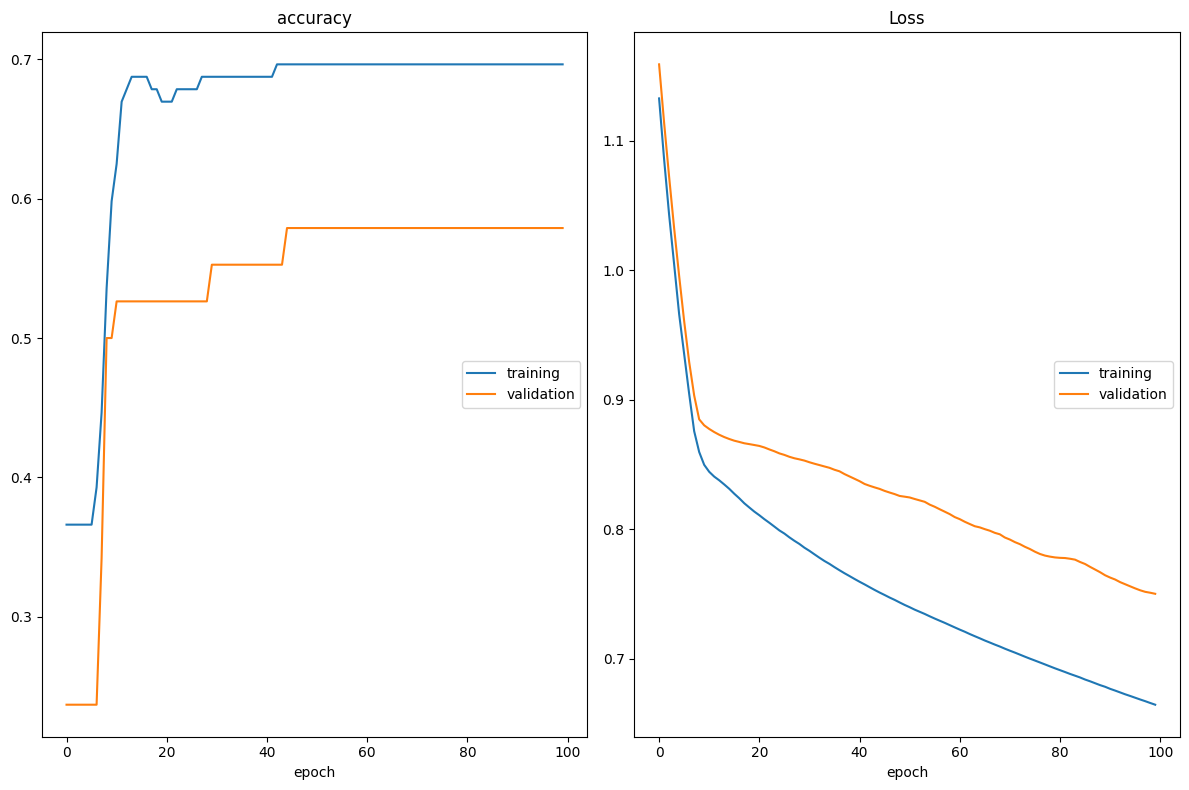

accuracy
	training         	 (min:    0.366, max:    0.696, cur:    0.696)
	validation       	 (min:    0.237, max:    0.579, cur:    0.579)
Loss
	training         	 (min:    0.665, max:    1.133, cur:    0.665)
	validation       	 (min:    0.750, max:    1.159, cur:    0.750)
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.6713 - loss: 0.6767 - val_accuracy: 0.5789 - val_loss: 0.7502


In [17]:
irisModel.fit(x_train,y_train_encoded,epochs=100,validation_data=(x_test,y_test_encoded),callbacks=[PlotLossesKerasTF()])

In [18]:
y_train.value_counts()

,count
Species,
Iris-virginica,41
Iris-setosa,37
Iris-versicolor,34


# Overfitting: L2 Regularization

In [19]:
from tensorflow.keras.regularizers import l2,l1,L1L2

In [22]:
irisModel=Sequential()

irisModel.add(Input(shape=(4,)))

irisModel.add(Dense(8,activation='relu',kernel_regularizer=l2(l2=0.2)))
irisModel.add(Dense(6,activation='relu',kernel_regularizer=l2(l2=0.1)))
irisModel.add(Dense(3,activation='softmax'))

irisModel.compile(loss="sparse_categorical_crossentropy",optimizer='adam',metrics=['accuracy'])

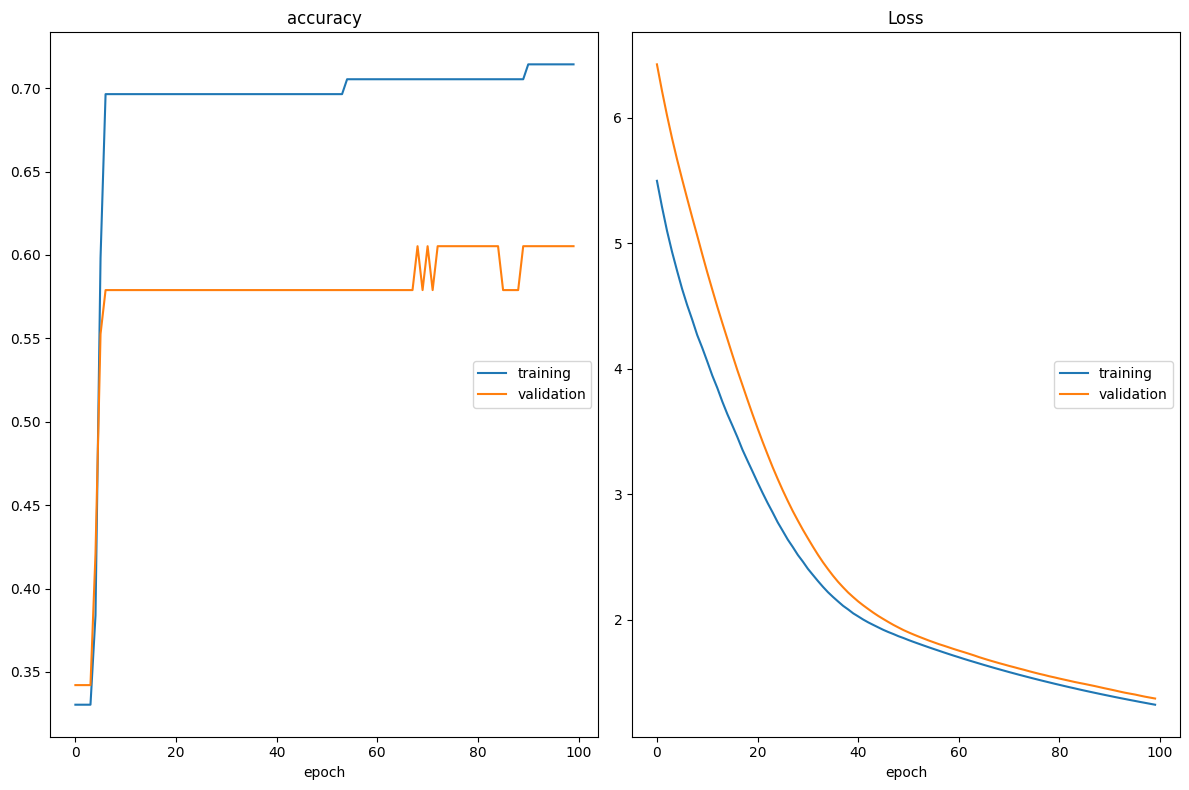

accuracy
	training         	 (min:    0.330, max:    0.714, cur:    0.714)
	validation       	 (min:    0.342, max:    0.605, cur:    0.605)
Loss
	training         	 (min:    1.324, max:    5.497, cur:    1.324)
	validation       	 (min:    1.373, max:    6.424, cur:    1.373)
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.7045 - loss: 1.3263 - val_accuracy: 0.6053 - val_loss: 1.3729


In [23]:
irisModel.fit(x_train,y_train_encoded,epochs=100,validation_data=(x_test,y_test_encoded),callbacks=[PlotLossesKerasTF()])

**L1 Regularization**

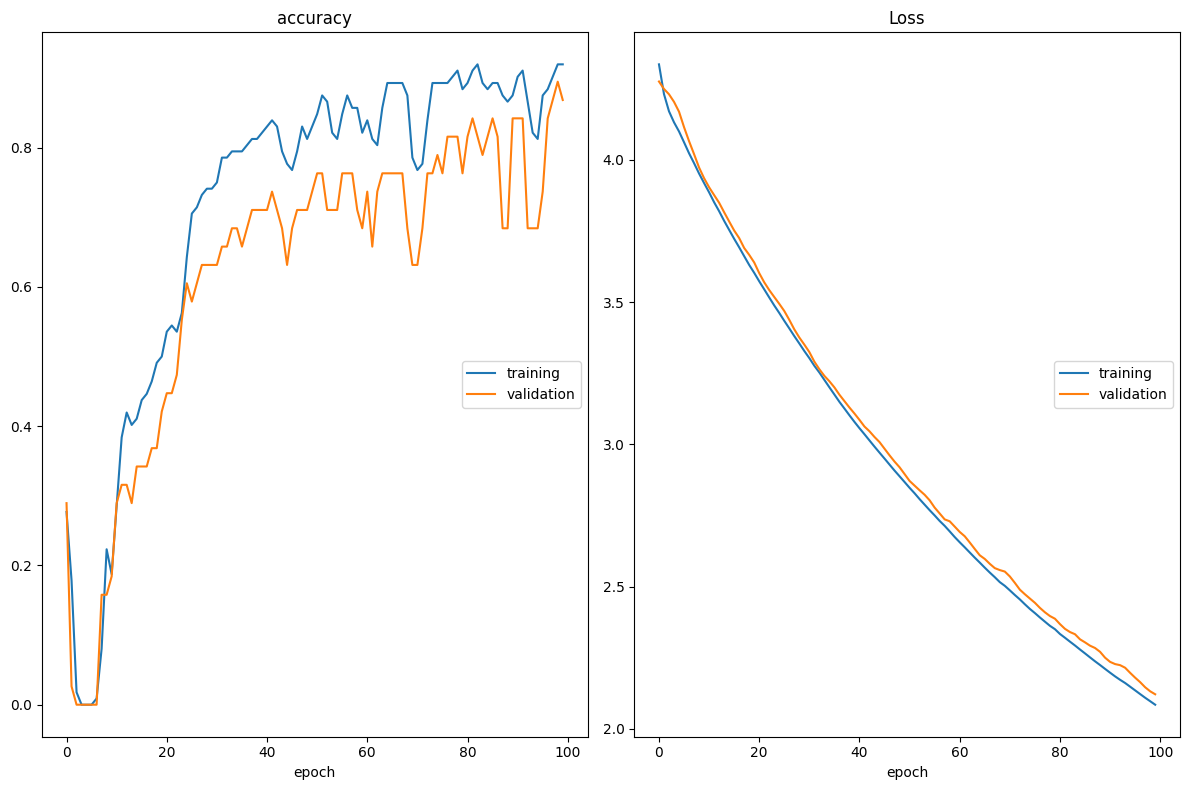

accuracy
	training         	 (min:    0.000, max:    0.920, cur:    0.920)
	validation       	 (min:    0.000, max:    0.895, cur:    0.868)
Loss
	training         	 (min:    2.085, max:    4.335, cur:    2.085)
	validation       	 (min:    2.122, max:    4.275, cur:    2.122)
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.8949 - loss: 2.0900 - val_accuracy: 0.8684 - val_loss: 2.1219


In [24]:
irisModel=Sequential()
irisModel.add(Input(shape=(4,)))
irisModel.add(Dense(8,activation='relu',kernel_regularizer=l1(l1=0.1)))
irisModel.add(Dense(6,activation='relu',kernel_regularizer=l1(l1=0.1)))
irisModel.add(Dense(3,activation='softmax'))
irisModel.compile(loss="sparse_categorical_crossentropy",optimizer='adam',metrics=['accuracy'])

irisModel.fit(x_train,y_train_encoded,epochs=100,validation_data=(x_test,y_test_encoded),callbacks=[PlotLossesKerasTF()])

**L1L2 Regularization**

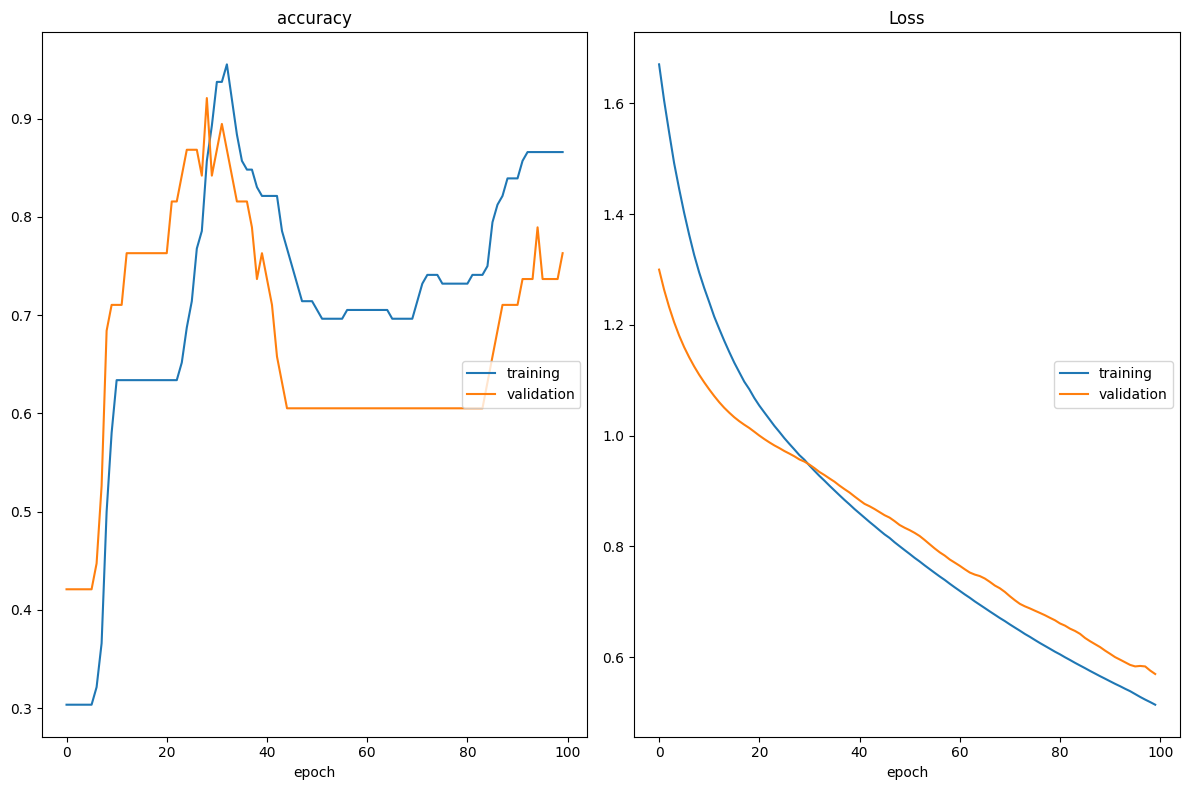

accuracy
	training         	 (min:    0.304, max:    0.955, cur:    0.866)
	validation       	 (min:    0.421, max:    0.921, cur:    0.763)
Loss
	training         	 (min:    0.514, max:    1.670, cur:    0.514)
	validation       	 (min:    0.570, max:    1.300, cur:    0.570)
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.8454 - loss: 0.5315 - val_accuracy: 0.7632 - val_loss: 0.5697


In [25]:
irisModel=Sequential()
irisModel.add(Input(shape=(4,)))
irisModel.add(Dense(8,activation='relu',kernel_regularizer=L1L2(l1=0.001,l2=0.005)))
irisModel.add(Dense(6,activation='relu',kernel_regularizer=L1L2(l1=0.001,l2=0.005)))
irisModel.add(Dense(3,activation='softmax'))
irisModel.compile(loss="sparse_categorical_crossentropy",optimizer='adam',metrics=['accuracy'])

irisModel.fit(x_train,y_train_encoded,epochs=100,validation_data=(x_test,y_test_encoded),callbacks=[PlotLossesKerasTF()])

In [26]:
from sklearn.metrics import classification_report

In [27]:
test_pred = irisModel.predict(x_test).argmax(axis=1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


In [28]:
test_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 2, 2, 2, 0, 2, 2, 0, 0, 2, 2,
       0, 0, 2, 0, 0, 1, 1, 0, 2, 2, 0, 2, 2, 2, 0, 2])

In [ ]:
#y_test_multiclass =y_test_encoded.argmax(axis=1)

AxisError: axis 1 is out of bounds for array of dimension 1

In [30]:
print(classification_report(y_test_encoded,test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.44      0.61        16
           2       0.50      1.00      0.67         9

    accuracy                           0.76        38
   macro avg       0.83      0.81      0.76        38
weighted avg       0.88      0.76      0.76        38



**Early Stopping**

In [31]:
irisModel=Sequential()
irisModel.add(Input(shape=(4,)))

irisModel.add(Dense(8,activation='relu',kernel_regularizer=L1L2(l1=0.001,l2=0.005)))
irisModel.add(Dense(6,activation='relu',kernel_regularizer=L1L2(l1=0.001,l2=0.005)))

irisModel.add(Dense(3,activation='softmax'))
irisModel.compile(loss="sparse_categorical_crossentropy",optimizer='adam',metrics=['accuracy'])

In [32]:
from tensorflow.keras.callbacks import EarlyStopping
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto"
   )

In [33]:
irisModel.fit(x_train,y_train_encoded,epochs=1000,validation_data=(x_test,y_test_encoded),callbacks=callback)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.3446 - loss: 1.6460 - val_accuracy: 0.3421 - val_loss: 1.5944
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3124 - loss: 1.5931 - val_accuracy: 0.3421 - val_loss: 1.5013
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3488 - loss: 1.4375 - val_accuracy: 0.3421 - val_loss: 1.4174
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3478 - loss: 1.3478 - val_accuracy: 0.3421 - val_loss: 1.3420
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3040 - loss: 1.3379 - val_accuracy: 0.3421 - val_loss: 1.2754
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3144 - loss: 1.2618 - val_accuracy: 0.3421 - val_loss: 1.2172
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2936 - loss: 1.2052 - val_accuracy: 0.3421 - val_loss: 1.1658
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3420 - loss: 1.1058 - val_accuracy: 0.3947 - v

**Dropout Techniques**

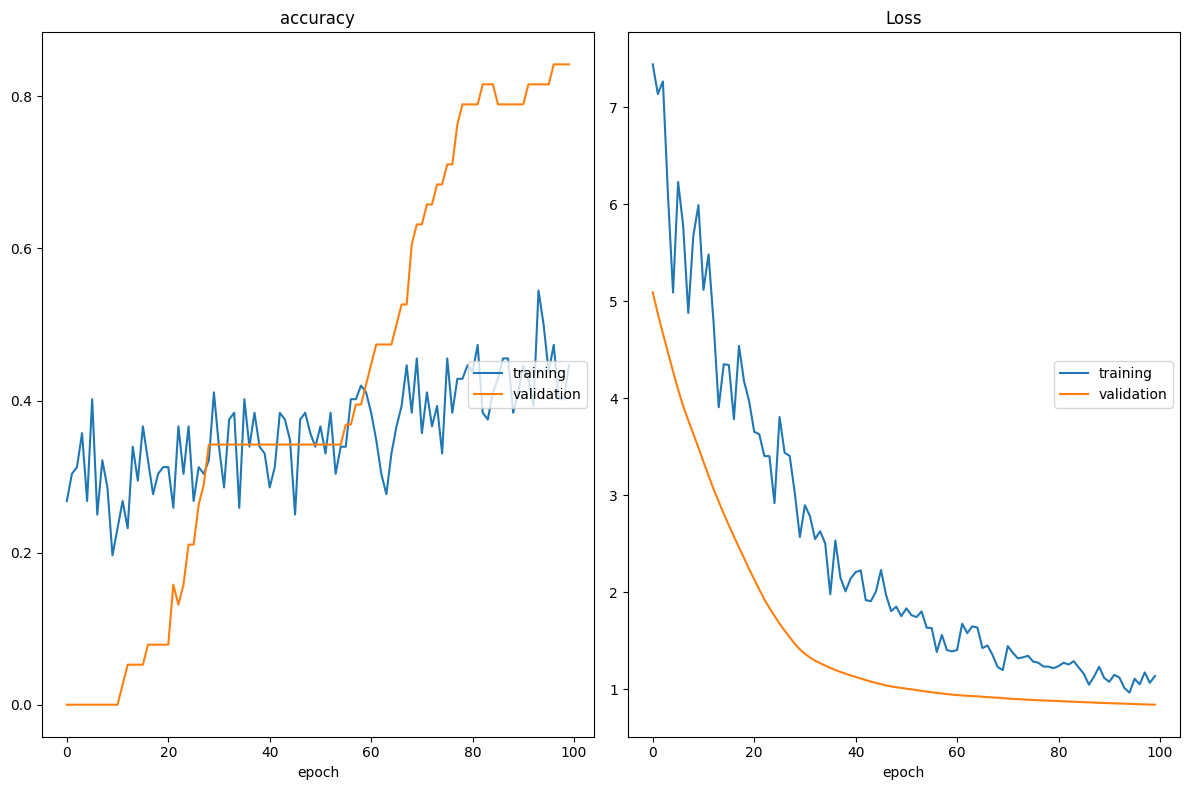

accuracy
	training         	 (min:    0.196, max:    0.545, cur:    0.446)
	validation       	 (min:    0.000, max:    0.842, cur:    0.842)
Loss
	training         	 (min:    0.965, max:    7.444, cur:    1.136)
	validation       	 (min:    0.840, max:    5.092, cur:    0.840)
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.4682 - loss: 1.1228 - val_accuracy: 0.8421 - val_loss: 0.8404


In [34]:
# Dropout
from tensorflow.keras.layers import Dense, Dropout,Input

irisModel2=Sequential()
irisModel2.add(Input(shape=(4,)))

irisModel2.add(Dense(8,activation='relu'))
irisModel2.add(Dropout(0.4))

irisModel2.add(Dense(6,activation='relu'))
irisModel2.add(Dropout(0.4))


irisModel2.add(Dense(3,activation='softmax'))
irisModel2.compile(loss="sparse_categorical_crossentropy",optimizer='adam',metrics=['accuracy'])

irisModel2.fit(x_train,y_train_encoded,epochs=100,validation_data=(x_test,y_test_encoded),callbacks=[PlotLossesKerasTF()])